In [1]:
import arviz as az
import emcee
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import warnings

logsumexp = az.stats.stats_utils.logsumexp

In [2]:
xdata = np.linspace(0,50,500)
b0, b1, sigma = -2, 1, 3
ydata = np.random.normal(loc=b1*xdata + b0, scale=sigma)

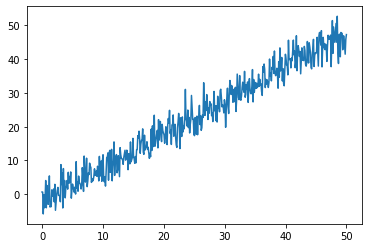

In [3]:
plt.plot(xdata, ydata)

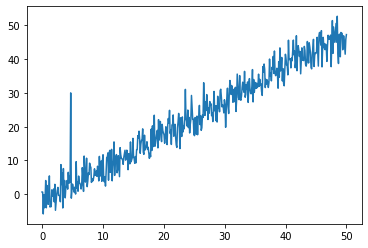

In [4]:
ydata[47] = 30
plt.plot(xdata, ydata)

In [5]:
def log_prior(theta):
    s_e = theta[-1]
    if s_e<=0:
        return -np.inf
    return -np.log(s_e)

def log_like(observations, theta):
    b0,b1,s_e = theta
    y, x = observations
    n = len(y)
    vect_like = b1*x+b0
    vect_like = -np.log(2*np.pi*s_e**2)/2-(y-vect_like)**2/(2*s_e**2)
    return vect_like

def model(theta,x):
    y_hat = (
        theta[0]
        +x*theta[1]
        +np.random.normal(scale=theta[-1])
    )
    return y_hat

def log_prob(theta,y,x):
    prior = log_prior(theta)
    if not np.isfinite(prior):
        return -np.inf, (np.full_like(y,np.nan), np.full_like(y,np.nan))
    vect_like = log_like((x, y), theta)
    like = np.sum(vect_like)
    return like+prior, (vect_like, model(theta,x))

In [6]:
nwalkers, ndim  = 40, 3
init_guess = np.array([0, 1, 1])
pos = init_guess + np.random.normal(scale=2, size=(nwalkers, ndim))

In [7]:
args = (ydata, xdata)
ndraws = 5000
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=args)
sampler.run_mcmc(pos, ndraws);

/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/emcee/moves/red_blue.py:97: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]


In [8]:
dims = {"y": ["time"], "x": ["time"], "log_likelihood": ["time"]}
idata = az.from_emcee(sampler, 
                      var_names=["b0", "b1", "s_e"],
                      arg_names=["y", "x"],
                      blob_names=["log_likelihood", "y"],
                      blob_groups=["sample_stats", "posterior_predictive"],
                      dims=dims)
idata.sel(draw=slice(1000, None))

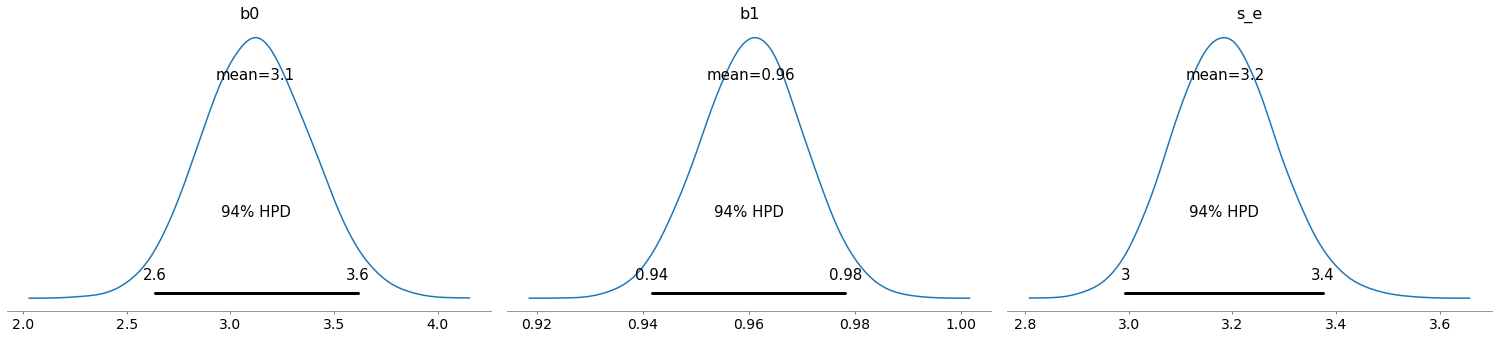

In [9]:
az.plot_posterior(idata);

In [10]:
class EmceeSamplingWrapper(az.SamplingWrapper):
    """Emcee wrapper."""
    
    def get_inference_data(self, sampler):
        """Should be quite general."""
        kwargs = {**self.idata_kwargs}
        burnin = kwargs.pop("discard", 200)
        idata = az.from_emcee(sampler, **kwargs)
        idata.sel(draw=slice(burnin, None))
        return idata
    
    def sel_observations(self, idx):
        y, x = idata.observed_data.to_array().values
        idxs = np.arange(len(y))
        mask = idxs == idx
        return (y[~mask], x[~mask]), (y[mask], x[mask])
    
    def sample(self, new_obs_data):
        """Should also be very general, as long as sel_observations is coherent with this."""
        sampler = self.model
        sampler.log_prob_fn.args = new_obs_data
        sampler.reset()
        sampler.run_mcmc(**self.sample_kwargs)
        return sampler

In [11]:
sample_kwargs = {"initial_state": pos, "nsteps": ndraws}
idata_kwargs = {
    "var_names": ["b0", "b1", "s_e"], 
    "arg_names": ["y", "x"],
    "blob_names": ["log_likelihood", "y"],
    "blob_groups": ["sample_stats", "posterior_predictive"],
    "dims": dims,
    "discard": 1000,
}
emcee_wrapper = EmceeSamplingWrapper(
    sampler, 
    idata_orig=idata, 
    log_like_fun=log_like,
    sample_kwargs=sample_kwargs, 
    idata_kwargs=idata_kwargs
)

In [12]:
def reloo(wrapper, loo_orig=None):
    if loo_orig is None:
        loo_orig = az.loo(wrapper.idata_orig, pointwise=True)
    reloo = loo_orig.copy()
    khats = reloo.pareto_k
    loo_i = reloo.loo_i
    scale = loo_orig.loo_scale
    if scale.lower() == "deviance":
        scale_value = -2
    elif scale.lower() == "log":
        scale_value = 1
    elif scale.lower() == "negative_log":
        scale_value = -1
    lppd_orig = loo_orig.p_loo + loo_orig.loo / scale_value
    n_data_points = loo_orig.n_data_points
    if np.any(khats>.7):
        lppd = np.empty(np.sum(khats.values>.7))
        for count, idx in enumerate(np.argwhere(khats.values>.7)):
            new_obs, excluded_obs = wrapper.sel_observations(idx)
            fit = wrapper.sample(new_obs)
            idata_idx = wrapper.get_inference_data(fit)
            psisloo_subset = az.loo(idata_idx, pointwise=True)
            ndraws = idata_idx.posterior.dims["draw"]
            nchains = idata_idx.posterior.dims["chain"]
            log_like_idx = az.wrap_xarray_ufunc(
                lambda pars: wrapper.point_log_likelihood(excluded_obs, pars),
                idata_idx.posterior.to_array(),
                func_kwargs={"out": np.empty((nchains, ndraws))},
                ufunc_kwargs={"n_dims": 1,"ravel": False},
                input_core_dims=[["variable"]],
            ).stack(sample=("chain", "draw"))
            loo_lppd_idx = scale_value * logsumexp(log_like_idx.values.flatten())
            khats[idx] = 0
            loo_i[idx] = loo_lppd_idx
            log_likelihood_i = idata_idx.sample_stats.log_likelihood.stack(sample=("chain", "draw"))
            log_likelihood = np.concatenate((log_likelihood_i.values, log_like_idx.values[None, ...]), axis=0)
            print(log_likelihood.shape)
            lppd[count] = np.sum(
                az.wrap_xarray_ufunc(
                    logsumexp,
                    log_likelihood,
                    func_kwargs={"b_inv": loo_orig.n_samples},
                    ufunc_kwargs={"n_dims": 1, "ravel": False},
                    input_core_dims= [["sample"]],
                )
            )
        reloo.loo = loo_i.values.sum()
        reloo.loo_se = (n_data_points * np.var(loo_i.values)) ** 0.5
        reloo.p_loo = lppd.mean() - reloo.loo / scale_value
        print("lppd_orig  :  recalculated")
        print(lppd_orig, lppd.mean())
        print(lppd_orig - reloo.loo / scale_value, reloo.p_loo)
        return reloo
    else:
        print("No problematic observations")
        return loo_orig

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    loo_orig = az.loo(idata, pointwise=True, scale="log")
loo_orig

/home/oriol/Public/arviz/arviz/stats/stats_utils.py:472: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "histogram" failed type inference due to: non-precise type pyobject
[1] During: typing of argument at /home/oriol/Public/arviz/arviz/stats/stats_utils.py (474)

File "arviz/stats/stats_utils.py", line 474:
def histogram(data):
    kcounts, _ = np.histogram(data, bins=[-np.Inf, 0.5, 0.7, 1, np.Inf])
    ^

  @conditional_jit
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numba/compiler.py:725: NumbaWarning: Function "histogram" was compiled in object mode without forceobj=True.

File "arviz/stats/stats_utils.py", line 473:
@conditional_jit
def histogram(data):
^

  self.func_ir.loc))
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numba/compiler.py:734: NumbaDeprecationWarning: 
Fall-back from the nopython compilation path to the object mode compilation path has been detected, this is deprecated behaviour.

For more

Computed from 160000 by 500 log-likelihood matrix

         Estimate       SE
elpd_loo -1292.53    41.64
p_loo        8.00        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      499   99.8%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    0    0.0%

In [14]:
reloo_data = reloo(emcee_wrapper, loo_orig=loo_orig)

/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/emcee/moves/red_blue.py:97: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
/home/oriol/Public/arviz/arviz/stats/stats.py:677: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numpy/core/_methods.py:36: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial)


(500, 160000)
lppd_orig  :  recalculated
-1284.5273331853714 -1274.0994668331823
-16.515148372599924 -6.087282020410839


In [15]:
az.ELPDData(reloo_data)

Computed from 160000 by 500 log-likelihood matrix

         Estimate       SE
elpd_loo -1268.01    20.25
p_loo       -6.09        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      500  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%